# Buổi 1 — Forecasting là gì

**Một câu:** một dự báo chỉ "tốt" khi được chấm trên dữ liệu **nó chưa thấy**, **so với một cách đơn giản** (baseline),
bằng **thước đo khớp với quyết định** mà nó phục vụ.

Tình huống: một công ty điện mỗi tối Chủ nhật phải đặt mua điện từng giờ cho 7 ngày tới (168 giờ) cho một hộ gia đình.
Code ban đầu báo sai số 0,380 kWh/giờ — trông rất tốt. Năm phần dưới cho thấy vì sao con số đó không nói lên gì.

## 0. Dữ liệu

**Bộ dữ liệu Individual Household Electric Power Consumption.** Một hộ gia đình ở Sceaux, ngoại ô Paris, gắn công tơ ghi số **mỗi phút** từ 16/12/2006 tới 26/11/2010 — gần
4 năm, hơn 2 triệu dòng. Chỉ có một tệp `household_power_consumption.txt`, các cột cách nhau bằng dấu `;`, số đo bị mất
ghi là `?`.

Nguồn: Hebrail, G. & Berard, A. (2006). Individual Household Electric Power Consumption [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C58K54. Giấy phép CC BY 4.0.

| Cột | Nghĩa |
|---|---|
| `Date`, `Time` | ngày (ngày/tháng/năm) và phút đo |
| `Global_active_power` | **công suất** cả nhà đang dùng trong phút đó, kW |
| `Global_reactive_power`, `Voltage`, `Global_intensity` | các đại lượng điện khác (công suất phản kháng, điện áp, cường độ) |
| `Sub_metering_1`, `_2`, `_3` | điện năng (Wh) của ba nhóm thiết bị: bếp; giặt giũ; bình nóng lạnh và máy lạnh |

Ô dưới tải dữ liệu (21 MB) một lần rồi kiểm **sha256** — "dấu vân tay" tính từ nội dung tệp, sai một byte là ra chuỗi khác hẳn. Khớp nghĩa là bạn đang có đúng tệp mà mọi con số dưới đây được tính ra.

In [ ]:
import hashlib
import os
import urllib.request
from pathlib import Path

# tên bộ: (sha256, [nơi tải, thử lần lượt])
DU_LIEU = {
    "uci-household-power": ("9f84b46ade8a2d8e1286ec4b2b6c2987a45a755c59f263be3b3b3d10dfbda3ff", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/uci-household-power/individual+household+electric+power+consumption.zip",
        "https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip",
    ]),
}
CACHE = Path(os.environ.get("KHOA_FORECASTING_CACHE") or Path.home() / ".cache" / "khoa-forecasting")


def sha256(tep: Path) -> str:
    h = hashlib.sha256()
    with open(tep, "rb") as f:
        for khoi in iter(lambda: f.read(1 << 20), b""):
            h.update(khoi)
    return h.hexdigest()


def lay(ten: str) -> Path:
    """Đường dẫn tệp đã kiểm sha256; chưa có thì tải về một lần."""
    sha, urls = DU_LIEU[ten]
    tep = CACHE / "sha256" / sha[:2] / sha
    if tep.is_file() and sha256(tep) == sha:
        return tep
    tep.parent.mkdir(parents=True, exist_ok=True)
    for url in urls:
        try:
            urllib.request.urlretrieve(url, tep)
            if sha256(tep) == sha:
                return tep
            print("sha256 không khớp:", url)
        except OSError as loi:
            print("tải lỗi:", url, loi)
    raise RuntimeError(f"không tải được {ten} khớp sha256")


for ten in DU_LIEU:
    print(f"{ten:<28} {lay(ten)}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TAM = 168             # dự báo 168 giờ = 7 ngày
MOC = "2010-01-04"    # dùng dữ liệu trước mốc để dự báo, chấm trên năm 2010

df = pd.read_csv(lay("uci-household-power"), compression="zip", sep=";", na_values="?",
                 usecols=["Date", "Time", "Global_active_power"])
phut = pd.Series(df["Global_active_power"].to_numpy(),
                 index=pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%Y %H:%M:%S"))
# trung bình kW trong một giờ = số kWh của giờ đó; giờ mất quá nửa số đo thì để trống
s = phut.resample("h").mean().where(phut.resample("h").count() >= 30)["2006-12-17":"2010-11-21 23:00"]
print(f"{len(s):,} giờ, trống {s.isna().sum()}, trung bình {s.mean():.2f} kWh/giờ")

## 1. Dự báo là điều sẽ xảy ra, không phải điều ta muốn — và phải hỏi đúng trước khi làm

**Vấn đề.** Sếp muốn bán 2.500 ly cà phê nên bảo "dự báo 2.500". Kho đặt hàng theo đó, tuần ấy bán 1.900: thừa nguyên
liệu 600 ly, và không ai còn biết dự báo đúng hay sai.

> **biến mục tiêu** · *target variable*
>
> - **Là gì:** đại lượng ta cần dự báo — cột `y` của bài toán.
> - **Ví dụ:** ở đây là số kWh hộ gia đình dùng trong mỗi giờ.
> - **Để làm gì:** chốt nó trước tiên: đổi biến mục tiêu (kWh/giờ hay kWh/ngày) là đổi cả bài toán.

> **gốc dự báo, mốc cắt dữ liệu** · *forecast origin, data cutoff*
>
> - **Là gì:** thời điểm ra dự báo; từ đó trở đi coi như chưa biết gì. Mốc cắt là giờ cuối cùng đã có số đo.
> - **Ví dụ:** tối Chủ nhật 23:59 là mốc cắt; 00:00 thứ Hai là gốc dự báo cho tuần tới.
> - **Để làm gì:** chỉ số liệu trước gốc mới được dùng — nếu lỡ dùng số sau gốc, kết quả chấm sẽ đẹp giả.

> **tầm dự báo, h** · *forecast horizon*
>
> - **Là gì:** dự báo xa bao nhiêu bước kể từ gốc; $h$ = 1 là bước đầu tiên.
> - **Ví dụ:** dự báo từng giờ cho 7 ngày thì $h$ = 1, 2, …, 168.
> - **Để làm gì:** quyết định được nhìn vào đâu: tầm 168 giờ thì không dùng được số của "hôm qua" cho thứ Sáu.
>
> 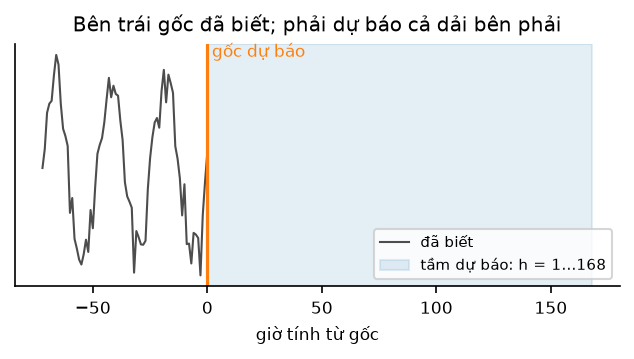

> **độ chi tiết** · *granularity*
>
> - **Là gì:** dữ liệu (và dự báo) gộp tới mức nào — theo giờ, ngày, tuần; theo từng hộ hay cả khu.
> - **Ví dụ:** cùng dữ liệu, có thể dự báo kWh từng giờ hoặc tổng kWh cả tuần.
> - **Để làm gì:** phải khớp với quyết định: mua điện từng giờ thì chấm từng giờ; mua cả khối tuần thì chấm tổng tuần.

> **công suất (kW), điện năng (kWh)** · *power, energy*
>
> - **Là gì:** công suất là nhà đang dùng điện mạnh cỡ nào tại một lúc; điện năng là tổng đã dùng = công suất × thời gian.
> - **Ví dụ:** bật lò 2 kW trong nửa giờ tốn 2 × 0,5 = 1 kWh. Trung bình kW trong một giờ chính là số kWh của giờ đó.
> - **Để làm gì:** công tơ ghi kW từng phút, công ty mua bán kWh — phải đổi đúng đơn vị trước khi làm gì.

> **dịch mức** · *level shift*
>
> - **Là gì:** mức trung bình của chuỗi đổi hẳn sang một mức mới rồi ở luôn đó.
> - **Ví dụ:** nhà có thêm người ở: từ 1,0 lên 1,4 kWh/giờ và không quay lại.
> - **Để làm gì:** sau một lần dịch mức, dữ liệu cũ kém giá trị — dấu hiệu "tương lai không còn giống quá khứ".
>
> 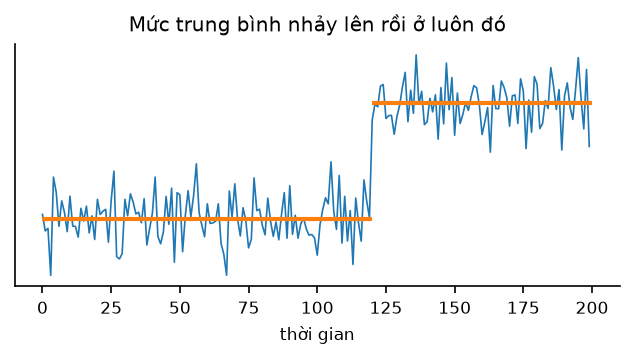

**Lý do.** **Dự báo** là điều *sẽ* xảy ra; **mục tiêu** là điều ta *muốn*; **kế hoạch** là việc ta *làm*. Trộn chúng thì
mất công cụ đo. Một thứ dự báo được tốt khi: (1) hiểu cái gì tác động tới nó, (2) có nhiều dữ liệu, (3) tương lai giống
quá khứ, (4) công bố dự báo không làm nó đổi. Điện một hộ ngày mai thoả cả bốn; tỷ giá tuần sau gần như chỉ thoả (2).

Trước khi mở dữ liệu, trả lời 6 câu — **phiếu bài toán**. Với công ty điện của ta:

| Câu | Trả lời |
|---|---|
| 1. Ai quyết định gì, bao lâu một lần? | tối Chủ nhật đặt mua điện từng giờ cho 7 ngày tới, mỗi tuần |
| 2. Dự báo cái gì, đơn vị? | kWh mỗi giờ |
| 3. Nhìn xa bao nhiêu (tầm dự báo)? | 168 giờ, từ 00:00 thứ Hai |
| 4. Chi tiết tới mức nào? | từng giờ (phần 5 đổi thành cả tuần) |
| 5. Lúc quyết định đã biết gì? | số đo tới 23:59 Chủ nhật |
| 6. Sai thì mất gì, mỗi chiều? | thiếu 1 kWh mất 4 đồng, thừa 1 kWh mất 1 đồng (phần 6) |

**Kết quả.** Điện của hộ này có nhịp rất đều — dấu hiệu dự báo được:

In [ ]:
print("giờ thấp nhất / cao nhất trong ngày:", s.groupby(s.index.hour).mean().idxmin(), "h /",
      s.groupby(s.index.hour).mean().idxmax(), "h")
print("TB thứ Hai–Sáu vs thứ Bảy–CN:", round(s[s.index.dayofweek < 5].mean(), 2), "vs", round(s[s.index.dayofweek >= 5].mean(), 2))
s.resample("D").sum(min_count=20).rolling(28, center=True, min_periods=14).mean().plot(
    figsize=(9, 2.5), ylabel="kWh/ngày", title="Mùa đông cao, tháng 8 vắng nhà, năm sau giống năm trước")
plt.show()

> **mùa vụ** · *seasonality*
>
> - **Là gì:** mẫu lên xuống lặp lại đều đặn theo lịch.
> - **Ví dụ:** ngày nào nhà này cũng thấp lúc 4 giờ sáng, cao lúc 20 giờ; năm nào tháng 8 cũng vắng nhà.
> - **Để làm gì:** là phần dễ dự báo nhất: biết giờ, thứ, tháng là đoán được một phần lớn con số.
>
> 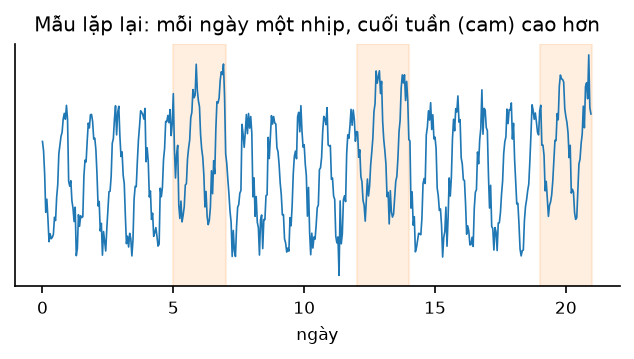

Nhịp theo ngày (thấp 4h, cao 20h), theo tuần (cuối tuần cao hơn), theo năm (mùa đông, kỳ nghỉ tháng 8). Nhịp lặp
lại theo lịch như vậy gọi là **mùa vụ**.

**Bài học.** Điền phiếu 6 câu trước khi làm gì khác: câu 3 và 5 quyết định được nhìn vào đâu, câu 4 quyết định chấm ở mức
nào, câu 6 quyết định nên báo con số nào.

## 2. Một con số sai số đứng một mình không nói gì

**Vấn đề.** MAE 0,380 kWh/giờ là tốt hay xấu?

> **baseline** · *baseline, benchmark forecast*
>
> - **Là gì:** cách dự báo thật đơn giản, ai cũng làm được, dùng làm mốc để so.
> - **Ví dụ:** "giờ này tuần sau giống giờ này tuần trước".
> - **Để làm gì:** một mô hình phức tạp mà không thắng nổi baseline thì bỏ — nó chỉ tốn công.

> **naive, seasonal naive** · *naive forecast, seasonal naive forecast*
>
> - **Là gì:** naive: lấy nguyên số cuối cùng đã biết. Seasonal naive: lấy số cùng thời điểm của vòng lặp trước.
> - **Ví dụ:** dự báo 19:00 thứ Ba — naive lấy số 23:00 Chủ nhật; seasonal naive lấy số 19:00 thứ Ba tuần trước.
> - **Để làm gì:** hai baseline chuẩn của mọi bài dự báo; chuỗi có mùa vụ thì seasonal naive thường khó thắng hơn nhiều.

> **sai số dự báo** · *forecast error*
>
> - **Là gì:** thực tế − dự báo, đo trên dữ liệu mô hình **chưa thấy**. Dương là dự báo thấp, âm là dự báo cao.
> - **Ví dụ:** thực tế 1,7 kWh, dự báo 1,5 → sai số +0,2 (dự báo thấp 0,2).
> - **Để làm gì:** là thứ duy nhất cho biết mô hình sẽ làm tốt tới đâu khi dùng thật.

> **MAE (sai số tuyệt đối trung bình)** · *mean absolute error*
>
> - **Là gì:** trung bình độ lớn các sai số, bỏ dấu.
> - **Ví dụ:** sai số +0,5; −0,5; +1,0; 0 → bỏ dấu 0,5; 0,5; 1,0; 0 → trung bình 0,5 kWh.
> - **Để làm gì:** một con số tóm "trung bình mỗi giờ lệch bao nhiêu", cùng đơn vị với dữ liệu, dễ nói với người không chuyên.

**Lý do.** Giống điểm 7: cả lớp được 9 thì 7 là kém, cả lớp được 4 thì 7 là giỏi. Baseline chính là "điểm của cả lớp".

**Kết quả.** Bốn baseline, chỉ dùng số đã biết trước lúc dự báo:

In [ ]:
def mae(y, du_bao):
    y, du_bao = np.asarray(y, float), np.asarray(du_bao, float)
    co = ~np.isnan(y)                                        # bỏ giờ không có số đo thật
    return float(np.mean(np.abs(y[co] - du_bao[co])))


BASELINE = {
    "giờ trước":         lambda ls: np.full(TAM, ls.iloc[-1]),                                   # số cuối đã biết
    "trung bình":        lambda ls: np.full(TAM, ls.mean()),                                    # TB mọi giờ đã biết
    "tuần trước":        lambda ls: ls.iloc[-TAM:].to_numpy(),                                  # cùng giờ tuần trước
    "trung bình 4 tuần": lambda ls: ls.iloc[-4 * TAM:].to_numpy().reshape(4, TAM).mean(axis=0), # TB 4 tuần cùng giờ
}

**Bài học.** Luôn báo MAE **cạnh** vài baseline. Và baseline cũng không được gian lận: "cùng giờ hôm qua" không dùng
được để dự báo thứ Sáu từ tối Chủ nhật — lúc đó chưa có số của thứ Năm.

## 3. Con số 0,380 là "sai số ảo": mô hình đã thấy trước đáp án

**Vấn đề.** "Mô hình" ban đầu là một **bảng lịch**: trung bình điện theo (tuần trong năm, thứ, giờ) — 8.904 ô. Nó được
lập từ **toàn bộ** 4 năm, rồi chấm trên năm 2010.

> **mô hình, tham số, khớp** · *model, parameter, fitting*
>
> - **Là gì:** mô hình là công thức ra dự báo; tham số là các con số bên trong nó; khớp là chọn các con số đó từ dữ liệu.
> - **Ví dụ:** bảng lịch là một mô hình có 8.904 tham số (mỗi ô một trung bình); tính các ô từ dữ liệu là khớp.
> - **Để làm gì:** nhiều tham số thì mô hình nhớ được nhiều chi tiết — nhưng cũng dễ học thuộc cả những chuyện tình cờ.

> **phần dư, sai số ảo** · *residual, in-sample error*
>
> - **Là gì:** phần dư là "sai số" đo trên chính dữ liệu đã dùng để khớp. Nó luôn đẹp hơn sai số thật — phần đẹp giả đó gọi là sai số ảo.
> - **Ví dụ:** học thuộc đáp án đề cũ rồi thi lại đúng đề đó được 10 điểm; đề mới chỉ được 6.
> - **Để làm gì:** để nhận ra và **không tin** con số chấm trên dữ liệu đã dùng; chỉ tin sai số dự báo.

**Lý do.** Năm 2010 nằm sẵn trong bảng. Xem ô dùng để dự báo 20:00 thứ Ba 26/10/2010:

**Kết quả.**

In [ ]:
def khoa(t):
    return [t.isocalendar().week.to_numpy(), t.dayofweek.to_numpy(), t.hour.to_numpy()]


def bang_lich(lich_su):
    return lich_su.groupby(khoa(lich_su.index)).mean()


def du_bao_lich(bang, t):
    return bang.reindex(pd.MultiIndex.from_arrays(khoa(t))).to_numpy()


k = khoa(s.index)
o = s[(k[0] == 43) & (k[1] == 1) & (k[2] == 20)]              # ô (tuần 43, thứ Ba, 20 giờ)
print(o.round(2).to_string())
that = o["2010-10-26"].iloc[0]
print(f"\ndự báo trung thực (3 năm trước): {o[o.index < '2010'].mean():.2f} → lệch {that - o[o.index < '2010'].mean():+.2f}")
print(f"dự báo nhìn trộm  (cả 4 số)    : {o.mean():.2f} → lệch {that - o.mean():+.2f}")

te = s[s.index >= MOC]
print(f"\nMAE bảng lịch lập từ cả 4 năm, chấm trên 2010: {mae(te, du_bao_lich(bang_lich(s), te.index)):.3f}")

Ô đó chứa **chính giờ đang cần đoán** (1,01 kWh ngày 26/10/2010). Tối Chủ nhật 24/10 ngoài đời, con số đó chưa tồn
tại. Đưa nó vào trung bình thì dự báo bị kéo về phía đáp án, sai số nhỏ đi — mô hình chẳng giỏi hơn chút nào. Tính trên cả
năm, khoảng **22%** số liệu trong mỗi ô là giờ đang chấm; kết quả là MAE **0,380**.

**Bài học.** Sai số đo trên dữ liệu đã dùng để dựng mô hình luôn đẹp giả. Đó là "sai số ảo", không phải sai số dự báo.

## 4. Chấm trung thực: dự báo cuốn — bảng lịch thua một phép trung bình

**Vấn đề.** Làm sao chấm như ngoài đời?

> **dự báo cuốn** · *rolling-origin forecast*
>
> - **Là gì:** lặp lại việc dự báo nhiều lần, mỗi lần dời gốc dự báo tới trước và chỉ dùng dữ liệu trước gốc đó.
> - **Ví dụ:** gốc 4/1/2010: dùng dữ liệu tới 3/1, dự báo 4–10/1, chấm. Gốc 11/1: thêm tuần vừa qua, dự báo 11–17/1, chấm. Cứ thế 46 tuần.
> - **Để làm gì:** mô phỏng đúng cách mô hình được dùng ngoài đời, nên cho sai số trung thực; chấm trên nhiều gốc thì kết luận không phụ thuộc may rủi của một tuần.
>
> 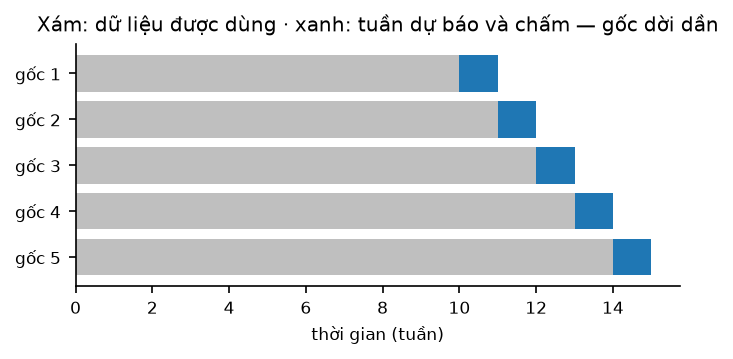

**Lý do.** Diễn lại đúng thứ tự thời gian bằng dự báo cuốn: mỗi tối Chủ nhật năm 2010 chỉ được dùng những gì đã xảy ra.

**Kết quả.**

In [ ]:
def du_bao_cuon(chuoi, moc=MOC):
    day_du = chuoi.fillna(chuoi.shift(TAM)).fillna(chuoi.shift(2 * TAM))     # vá giờ trống bằng tuần trước
    phan = []
    for goc in pd.date_range(moc, chuoi.index[-1] - pd.Timedelta(hours=TAM - 1), freq=f"{TAM}h"):
        t = pd.date_range(goc, periods=TAM, freq="h")
        truoc = chuoi.index < goc                                           # CHỈ quá khứ
        cot = {"goc": goc, "y": chuoi.reindex(t).to_numpy(),
               "bảng lịch": du_bao_lich(bang_lich(chuoi[truoc]), t)}
        for ten, ham in BASELINE.items():
            cot[ten] = ham(chuoi[truoc] if ten == "trung bình" else day_du[truoc])
        phan.append(pd.DataFrame(cot, index=t))
    return pd.concat(phan)


cuon = du_bao_cuon(s)
kq = pd.Series({c: mae(cuon["y"], cuon[c]) for c in cuon.columns[2:]}).sort_values()
print(f"{cuon['goc'].nunique()} tuần được chấm\n")
print(kq.round(3).to_string())

Chấm trung thực, bảng lịch lên **0,508** và **thua** "trung bình 4 tuần" (**0,490**) — một mô hình 8.904 con số thua
phép trung bình bốn số. Mỗi dòng của bảng kết quả là một giờ; cột `y` là thực tế, mỗi cột còn lại là một cách dự báo:

In [ ]:
cuon.loc["2010-10-26 19:00":"2010-10-26 21:00"].drop(columns="goc").round(2)

Phép thử nhanh để bắt nhìn trộm, dùng được cho mọi mô hình: **sửa đáp án** (cộng 5 kWh vào mọi giờ tuần cuối) rồi chạy
lại. Dự báo trung thực làm trước khi tuần đó xảy ra, nên **không được đổi**.

In [ ]:
s_gia = s.copy()
s_gia.iloc[-TAM:] += 5
gio = pd.Timestamp("2010-11-16 20:00")
print("dự báo cuốn 20:00 16/11 — trước:", round(du_bao_cuon(s, "2010-11-15").loc[gio, "bảng lịch"], 2),
      "| sau khi sửa đáp án:", round(du_bao_cuon(s_gia, "2010-11-15").loc[gio, "bảng lịch"], 2))
print("bảng lịch nhìn trộm  — trước:", round(du_bao_lich(bang_lich(s), pd.DatetimeIndex([gio]))[0], 2),
      "| sau khi sửa đáp án:", round(du_bao_lich(bang_lich(s_gia), pd.DatetimeIndex([gio]))[0], 2))

**Bài học.** Chấm bằng dự báo cuốn, chỉ dùng quá khứ. Mô hình nhìn trộm thì đổi theo đáp án giả; mô hình trung thực
đứng yên.

## 5. Chấm theo giờ hay theo tuần có thể đảo thứ hạng

**Vấn đề.** Nếu công ty mua một khối điện cho **cả tuần**, chỉ tổng tuần quan trọng. Thứ hạng còn giữ không?

**Lý do.** Cộng cả tuần thì lệch lên và lệch xuống ngẫu nhiên bù cho nhau; chỉ lệch **cùng một chiều** nhiều ngày mới dồn
lại. Bảng lịch nhớ kỳ nghỉ tháng 8; hai baseline thì không, nên chúng lệch cùng chiều suốt kỳ nghỉ.

**Kết quả.** Chỉ chấm tuần đủ số đo:

In [ ]:
cot = ["trung bình 4 tuần", "bảng lịch", "tuần trước"]
tuan = cuon.groupby("goc")[["y", *cot]].sum(min_count=1)
tuan.loc[~cuon.groupby("goc")["y"].apply(lambda x: x.notna().all()), "y"] = np.nan
print(pd.DataFrame({"MAE theo giờ": [mae(cuon["y"], cuon[c]) for c in cot],
                    "MAE tổng tuần": [mae(tuan["y"], tuan[c]) for c in cot]}, index=cot).round(3))

Theo giờ, trung bình 4 tuần đứng đầu; theo tổng tuần, bảng lịch thắng xa (16,4 so với 27,9 kWh/tuần).

**Bài học.** Chấm ở **đúng mức mà quyết định được đưa ra**. Đổi mức chấm là có thể đổi người thắng.

## 6. Khi thiếu đắt hơn thừa, đừng báo con số trung bình

**Vấn đề.** Thiếu 1 kWh phải mua gấp giá cao, mất **4 đồng**; thừa 1 kWh bán lỗ, mất **1 đồng**. Nên mua bao nhiêu?

> **thị trường kỳ hạn, giá giao ngay** · *forward market, spot price*
>
> - **Là gì:** kỳ hạn: mua trước, chốt giá hôm nay cho hàng giao sau. Giao ngay: mua đúng lúc cần, thường đắt hơn nhiều.
> - **Ví dụ:** Chủ nhật mua điện cho cả tuần (kỳ hạn); thứ Tư thiếu thì phải mua bù giá giao ngay.
> - **Để làm gì:** giải thích vì sao **thiếu** đắt hơn **thừa** — cơ sở để chọn con số nên báo.

> **phân phối** · *distribution*
>
> - **Là gì:** danh sách các giá trị có thể xảy ra, kèm mức độ hay gặp của từng giá trị.
> - **Ví dụ:** 10 ngày lúc 19 giờ nhà dùng 7, 5, 9, 6, 8, 12, 6, 9, 7, 8 kWh: hay gặp quanh 6–9, hiếm khi tới 12.
> - **Để làm gì:** cho biết không chỉ "thường bao nhiêu" mà cả "xấu nhất cỡ nào" — thứ cần khi sai số có giá.
>
> 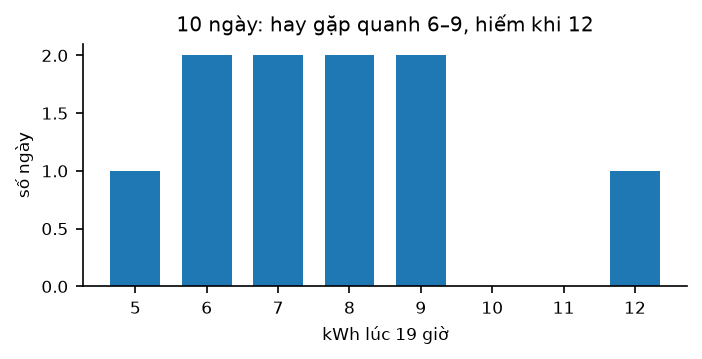

> **quantile, trung vị** · *quantile, median*
>
> - **Là gì:** quantile 0,8 là giá trị nhỏ nhất mà ít nhất 80% số liệu không vượt quá. Trung vị là quantile 0,5 — mốc chia đôi.
> - **Ví dụ:** xếp 10 số trên tăng dần 5, 6, 6, 7, 7, 8, 8, **9**, 9, 12; số thứ 0,8 × 10 = 8 là 9 → quantile 0,8 = 9 kWh.
> - **Để làm gì:** "mua 9 kWh thì đủ điện cho 80% số ngày" — biến phân phối thành một con số hành động được.
>
> 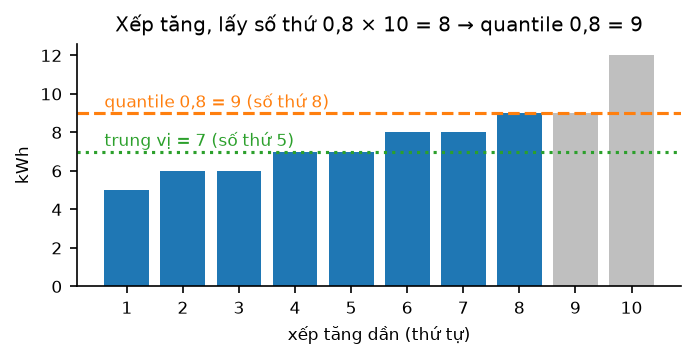

> **dự báo điểm, dự báo phân phối** · *point forecast, probabilistic forecast*
>
> - **Là gì:** dự báo điểm là một con số; dự báo phân phối là cả dải giá trị kèm khả năng.
> - **Ví dụ:** "mai bán 120 cái" so với "mai bán 100–140 cái, khả năng 80%".
> - **Để làm gì:** có phân phối thì với bất kỳ tỷ lệ chi phí nào cũng đọc ra được con số tốt nhất; một con số thì không.

> **bài toán newsvendor** · *newsvendor problem*
>
> - **Là gì:** đặt một lượng hàng một lần khi thiếu và thừa đều mất tiền (tên gốc: người bán báo nhập báo mỗi sáng).
> - **Ví dụ:** thiếu mất 4 đồng/kWh, thừa mất 1 đồng/kWh → nên mua ở quantile 4 / (4 + 1) = 0,8.
> - **Để làm gì:** cho công thức chọn con số: quantile mức chi phí thiếu / (chi phí thiếu + chi phí thừa).
>
> 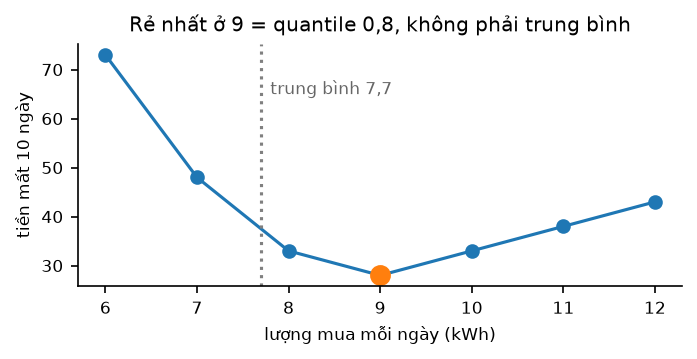

> **hàm phân phối tích luỹ** · *cumulative distribution function, CDF*
>
> - **Là gì:** với mỗi mốc $x$, tỷ lệ số liệu nhỏ hơn hoặc bằng $x$. Quantile là phép ngược của nó.
> - **Ví dụ:** với 10 ngày trên, tỷ lệ ngày dùng ≤ 8 kWh là 7/10 = 0,7; ≤ 9 kWh là 9/10 = 0,9.
> - **Để làm gì:** đọc ngược từ tỷ lệ ra mốc chính là tìm quantile — cách sách vở viết công thức newsvendor.
>
> 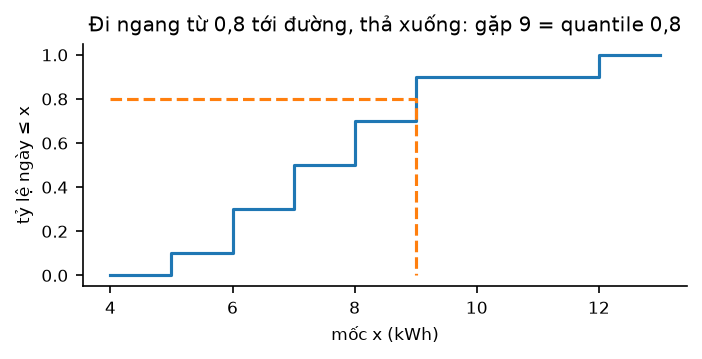

**Lý do.** Tăng lượng mua thêm 1 kWh: mỗi ngày đang thiếu đỡ 4 đồng, mỗi ngày đủ mất thêm 1 đồng. Còn lời chừng nào số
ngày thiếu còn nhiều hơn 1/5. Nên dừng ở mức mà **80%** số ngày đủ điện — quantile 0,8 = 4 / (4 + 1).

**Kết quả.** 10 ngày, nhà dùng 7, 5, 9, 6, 8, 12, 6, 9, 7, 8 kWh; thử từng mức mua:

In [ ]:
nhu_cau = np.array([7, 5, 9, 6, 8, 12, 6, 9, 7, 8])
chi_phi = {m: int(4 * np.clip(nhu_cau - m, 0, None).sum() + np.clip(m - nhu_cau, 0, None).sum()) for m in range(6, 13)}
print("mua (kWh) → tiền mất 10 ngày:", chi_phi)
print("quantile 0,8 của nhu cầu:", np.quantile(nhu_cau, 0.8, method="inverted_cdf"), "| trung bình:", nhu_cau.mean())

Rẻ nhất ở **9 kWh** = quantile 0,8, không phải trung bình 7,7. Trên dữ liệu thật: lấy sai số của năm 2009, cộng
quantile 0,8 của nó vào dự báo năm 2010:

In [ ]:
def tien_mat(y, f):
    d = np.asarray(y, float) - np.asarray(f, float)
    d = d[~np.isnan(d)]
    return float(np.mean(np.where(d > 0, 4 * d, -1 * d)))


c09 = du_bao_cuon(s[s.index < MOC], moc="2009-01-05")
q = float((c09["y"] - c09["trung bình 4 tuần"]).dropna().quantile(0.8))    # chọn từ 2009, không nhìn 2010
y, f = cuon["y"].to_numpy(), cuon["trung bình 4 tuần"].to_numpy()
print(f"cộng thêm {q:.3f} kWh mỗi giờ")
print(f"tiền mất/giờ: {tien_mat(y, f):.3f} → {tien_mat(y, f + q):.3f} | MAE: {mae(y, f):.3f} → {mae(y, f + q):.3f}")

Tiền mất giảm 18,6% trong khi MAE **tệ đi** — MAE phạt thiếu và thừa như nhau nên không thấy lợi của mua dư.

**Bài học.** Thước đo phải khớp với cái giá thật của sai lầm. Chấm bằng thước đo sai thì chọn sai.

## 7. Bài tập về nhà — đáp số

**Bài 2 — Gộp hai dự báo.** Lấy trung bình dự báo của "trung bình 4 tuần" và "bảng lịch":

In [ ]:
cuon["kết hợp"] = (cuon["trung bình 4 tuần"] + cuon["bảng lịch"]) / 2
cot = ["kết hợp", "trung bình 4 tuần", "bảng lịch"]
tuan = cuon.groupby("goc")[["y", *cot]].sum(min_count=1)
tuan.loc[~cuon.groupby("goc")["y"].apply(lambda x: x.notna().all()), "y"] = np.nan
print(pd.DataFrame({"MAE theo giờ": [mae(cuon["y"], cuon[c]) for c in cot],
                    "MAE tổng tuần": [mae(tuan["y"], tuan[c]) for c in cot]}, index=cot).round(3))

Theo giờ, bản gộp thắng cả hai (lỗi của hai cách bù cho nhau một phần); theo tuần, nó đứng giữa vì một nửa vẫn là
baseline không nhớ tháng 8.

**Bài 3 — Thiếu 1 đồng, thừa 3 đồng.** Mức nên mua = 1 / (1 + 3) = 0,25 → cộng quantile 0,25 của sai số 2009 (số âm: mua
ít hơn dự báo):

In [ ]:
def tien_mat_13(y, f):
    d = np.asarray(y, float) - np.asarray(f, float)
    d = d[~np.isnan(d)]
    return float(np.mean(np.where(d > 0, 1 * d, -3 * d)))


q25 = float((c09["y"] - c09["trung bình 4 tuần"]).dropna().quantile(0.25))
co = ~np.isnan(y)
print(f"cộng thêm {q25:+.3f} kWh | tiền mất/giờ: {tien_mat_13(y, f):.3f} → {tien_mat_13(y, f + q25):.3f}"
      f" | tỷ lệ giờ thiếu: {np.mean(y[co] > (f + q25)[co]):.0%}")

Mua ít hơn dự báo thì thiếu tới khoảng 3/4 số giờ — đúng ý đồ, vì thừa đắt gấp ba.

## Tự kiểm

- [ ] Giải thích vì sao 0,380 là sai số ảo, và vì sao bảng lịch (0,508) thua trung bình 4 tuần (0,490).
- [ ] Nói được phép thử "sửa đáp án" bắt nhìn trộm thế nào.
- [ ] Giải thích vì sao chấm theo tổng tuần thì thứ hạng đảo.
- [ ] Thiếu 4 đồng, thừa 1 đồng: vì sao mua ở quantile 0,8?